In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance

#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner
from scripts.feat_eng import apply_all

warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

#싸이킷런에서 인코딩 후 데이터를 판다스 데이터 프레임으로 남기기
set_config(transform_output="pandas")

In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

In [4]:
# merchant_df 컬럼명 변경
merchant_df.columns = ['mct_id', 'mct_address', 'mct_name', 'brand_code', 'sigungu', 'industry_name', 'commercial_area', 'open_date', 'close_date']

In [5]:
# sale_df 컬럼명 변경
sale_df.columns = ['mct_id', 'trans_date', 'operation_band', 'sale_amt_band', 'sale_cnt_band', 'unique_customer_band', 'aov_band', 'cancel_rate_band', 'delivery_sale_amount_ratio', 'industry_sale_amt_ratio', 'industry_sale_cnt_ratio',
                   'industry_sale_rank_pct', 'area_sale_rank_pct', 'industry_close_pct', 'area_close_pct']

In [6]:
# cust_df 컬럼명 변경
cust_df.columns = ['mct_id', 'trans_date', 'male_u20', 'male_u30', 'male_u40', 'male_u50', 'male_u60', 'female_u20', 'female_u30', 'female_u40', 'female_u50', 'female_u60', 
                   'visit_re', 'visit_new', 'route_resident', 'route_worker', 'route_floating']

# Feature Engineering

### merchant_df 기준으로 DataFrame 결합

#### sale_df 전처리

In [7]:
## 구간 데이터 전처리
# 복사본 생성
sale_df_prc = sale_df.copy()

# 구간 데이터 앞에 숫자만 빼오기
sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'] = sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'].apply(lambda x: x.str.split('_', expand=True)[0])

# 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
# 가정: 결측값의 경우 취소율이 적다고 판단!!
band_cols = sale_df_prc.loc[:, 'operation_band':'cancel_rate_band'].columns
sale_df_prc[band_cols] = sale_df_prc[band_cols].fillna(1).astype(int)

## 비율 데이터 전처리
# 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
sale_df_prc['delivery_sale_amount_ratio'] = sale_df_prc['delivery_sale_amount_ratio'].map(lambda x: 0 if x < 0 else x)

# 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
sale_df_prc['area_close_pct'] = sale_df_prc['area_close_pct'].map(lambda x: 0 if x < 0 else x)

# 가맹점별 매출정보 평균계산
sale_df_prc = sale_df_prc.drop('trans_date', axis=1).groupby('mct_id').mean().reset_index()

# sale_df_prc 데이터와 merchant_df 결합한 데이터 merged_df에 저장
merged_df = merchant_df.merge(sale_df_prc, on='mct_id')

### cust_df 전처리

In [8]:
## 고객 데이터 전처리
# 복사본 생성
cust_df_prc = cust_df.copy()

# 결측치는 0으로 대체
cust_cols = cust_df_prc.iloc[:, 2:].columns
cust_df_prc[cust_cols] = cust_df_prc[cust_cols].clip(lower=0)

#  가맹점별 고객정보 평균계산
cust_df_prc = cust_df_prc.drop('trans_date', axis=1).groupby('mct_id').mean().reset_index()

# cust_df_prc 데이터 merged_df에 추가
merged_df = merged_df.merge(cust_df_prc, on='mct_id')

### 범주형 데이터 그룹화
- 업종 통합 시 sale_df의 업종관련 정보와의 차이 발생 가능

In [9]:
## 업종 그룹화 
meat = ['한식-육류/고기',  '꼬치구이']
cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
enter = ['일반 유흥주점',  '룸살롱/단란주점']
convenience = ['샌드위치/토스트',  '도시락', '분식']
world_food = ['동남아/인도음식',  '기타세계요리']
dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품',  '건강원', '담배',  '식료품']

# replace 진행
groups_to_replace = [(meat, 'meat'), (cafe, 'cafe'), (k_food, 'k_food'), (w_food, 'w_food'), (j_food, 'j_food'),
                                       (c_food, 'c_food'), (drink, 'drink'), (product, 'product'), (enter, 'enter'), (convenience, 'convenience'),
                                       (world_food, 'world_food'), (dessert, 'dessert'), (others, 'others')]
replacement = {}
for ind, cat in groups_to_replace:
    for i in ind:
        replacement[i] = cat

merged_df['industry_name'].replace(replacement, inplace=True)

In [10]:
# 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                                    '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                                    '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}
merged_df['commercial_area'].replace(areas_to_replace, inplace=True)

# 상권 결측치는 Unknown으로 대체
merged_df['commercial_area'].fillna('Unknown', inplace=True)

In [11]:
# merchant_df.loc[merchant_df['mct_address'].str.contains('장터길')]

### is_closed 컬럼 생성

In [12]:
# 폐업여부 나타내는 is_closed 컬럼 추가
merged_df['is_closed'] = merged_df['close_date'].notna().astype(int)

### 불필요 컬럼 제거

In [13]:
# 기존 merchant_df에 존재했던 컬럼 중 모델에 사용할 수 없는 컬럼 제거
merged_df.drop(['mct_id', 'mct_address', 'mct_name', 'brand_code', 'sigungu', 'open_date', 'close_date'], axis=1, inplace=True)

In [14]:
# 상관계수 절댓값이 0.7 이상인 컬럼들이 있으면 둘 중 하나 제거
merged_df.drop(['sale_amt_band', 'unique_customer_band', 'industry_sale_cnt_ratio', 'industry_sale_rank_pct'], axis=1, inplace=True)

In [15]:
final_df = apply_all(merchant_df, sale_df, cust_df)

In [16]:
# plt.figure(figsize=(15, 10))
# test = merged_df.copy()
# test.drop(['sale_amt_band', 'unique_customer_band', 'industry_sale_cnt_ratio', 'industry_sale_rank_pct'], axis=1, inplace=True)
# sns.heatmap(test.select_dtypes(exclude='object').corr(), annot=True, fmt='.1f', cmap='RdBu')
# plt.show()

In [17]:
## ModelTuner 사용법

'''
#사용가능한 모델
logistic,knn,gnb,svc_linear,svc_rbf,xgb,lgbm

#모델 생성 및 데이터 입력
logistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)
xgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)

#모델 튜닝 및 평가
#tune_evals은 생략 가능
logistic_tuner.run(tune_evals=50)

#튜닝된 모델
logistic_tuner.final_model()

#최적의 파라미터
logistic_tuner.best_params()

#모델 성능 지표
logistic_tuner.evaluate()

'''

"\n#사용가능한 모델\nlogistic,knn,gnb,svc_linear,svc_rbf,xgb,lgbm\n\n#모델 생성 및 데이터 입력\nlogistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)\nxgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)\n\n#모델 튜닝 및 평가\n#tune_evals은 생략 가능\nlogistic_tuner.run(tune_evals=50)\n\n#튜닝된 모델\nlogistic_tuner.final_model()\n\n#최적의 파라미터\nlogistic_tuner.best_params()\n\n#모델 성능 지표\nlogistic_tuner.evaluate()\n\n"

### 인코딩

In [16]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation_band              4185 non-null   float64
 1   sale_cnt_band               4185 non-null   float64
 2   aov_band                    4185 non-null   float64
 3   cancel_rate_band            4185 non-null   float64
 4   delivery_sale_amount_ratio  4185 non-null   float64
 5   industry_sale_amt_ratio     4185 non-null   float64
 6   area_sale_rank_pct          4185 non-null   float64
 7   industry_close_pct          4185 non-null   float64
 8   area_close_pct              4185 non-null   float64
 9   male_u20                    4185 non-null   float64
 10  male_u30                    4185 non-null   float64
 11  male_u40                    4185 non-null   float64
 12  male_u50                    4185 non-null   float64
 13  male_u60                    4185 

In [17]:
y = final_df['is_closed']
X = final_df.drop(columns = ['is_closed'])

In [18]:
#학습, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ])
#주의: 테스트 셋에서 학습 데이터에 없는 값들이 무시될 수 있음 handle_unknown='ignore' 없는 것도 적용해 볼것
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)#학습, 검증 데이터 셋 분리

In [19]:
X_train.shape

(3348, 46)

### Logistic Regression

--- Logistic Regression 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



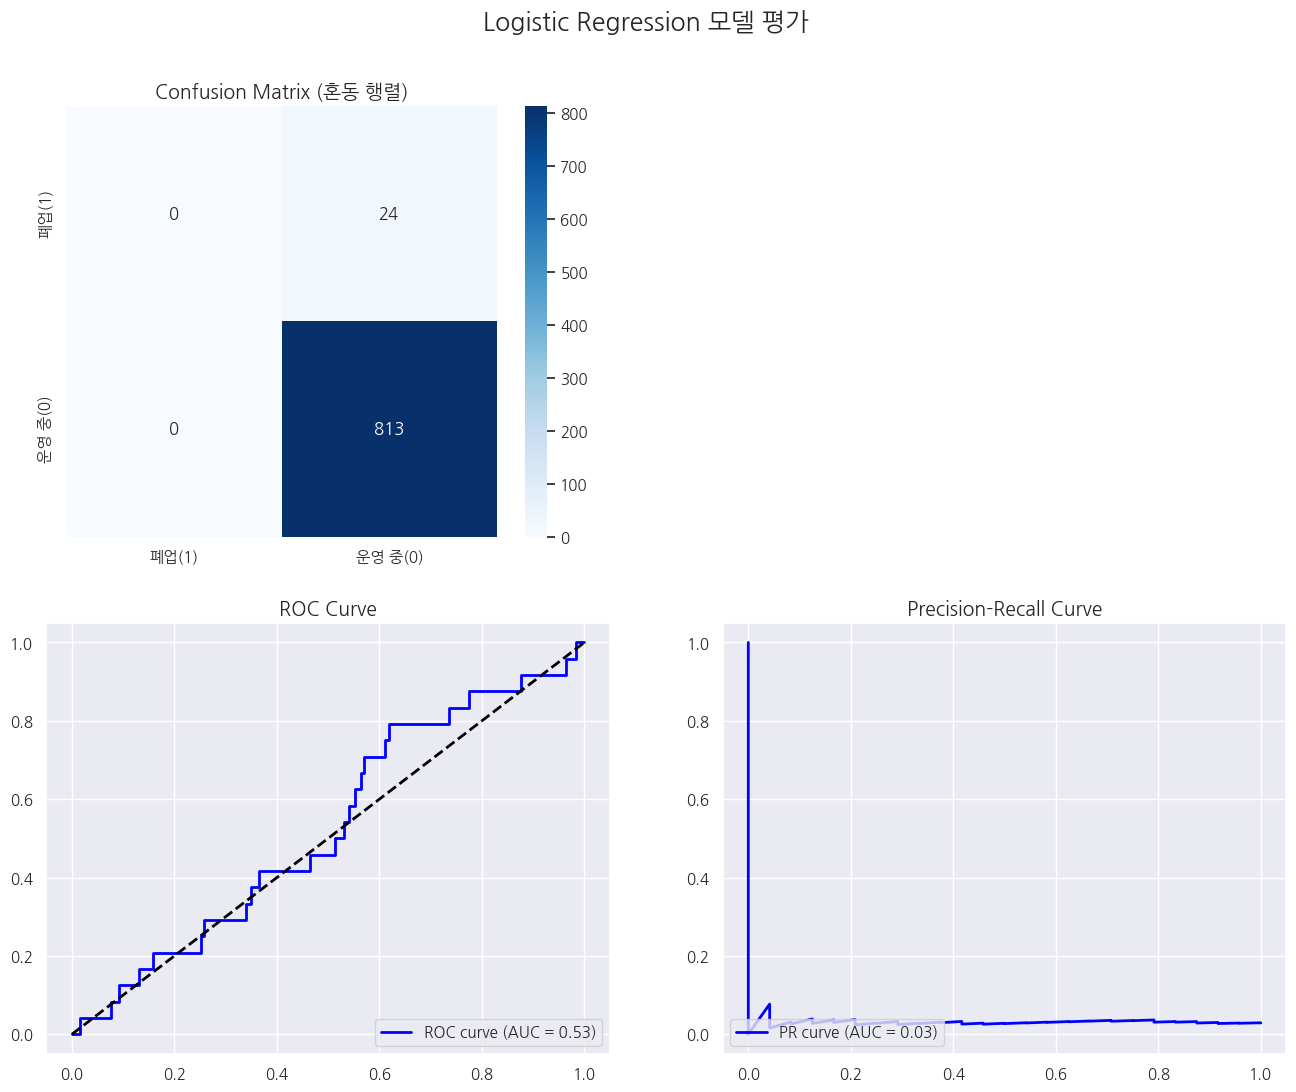

In [22]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train,y_train)

model_eval(model,"Logistic Regression",X_test,y_test)

--- logistic 모델의 하이퍼파라미터 튜닝 시작 ---
100%|████████████████████████████████████| 50/50 [00:58<00:00,  1.18s/trial, best loss: -0.5247619047619048]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(3.4796456979103736), 'class_weight': 'balanced', 'max_iter': np.float64(700.0), 'penalty': 'l2', 'solver': 'saga'}


최종 모델 학습 완료.
--- LOGISTIC 모델 평가 ---
정확도(Accuracy): 0.6165
정밀도(Precision): 0.0163
재현율(Recall): 0.2083
F1 점수(F1 Score): 0.0302
매튜 상관 계수(MCC): -0.0565



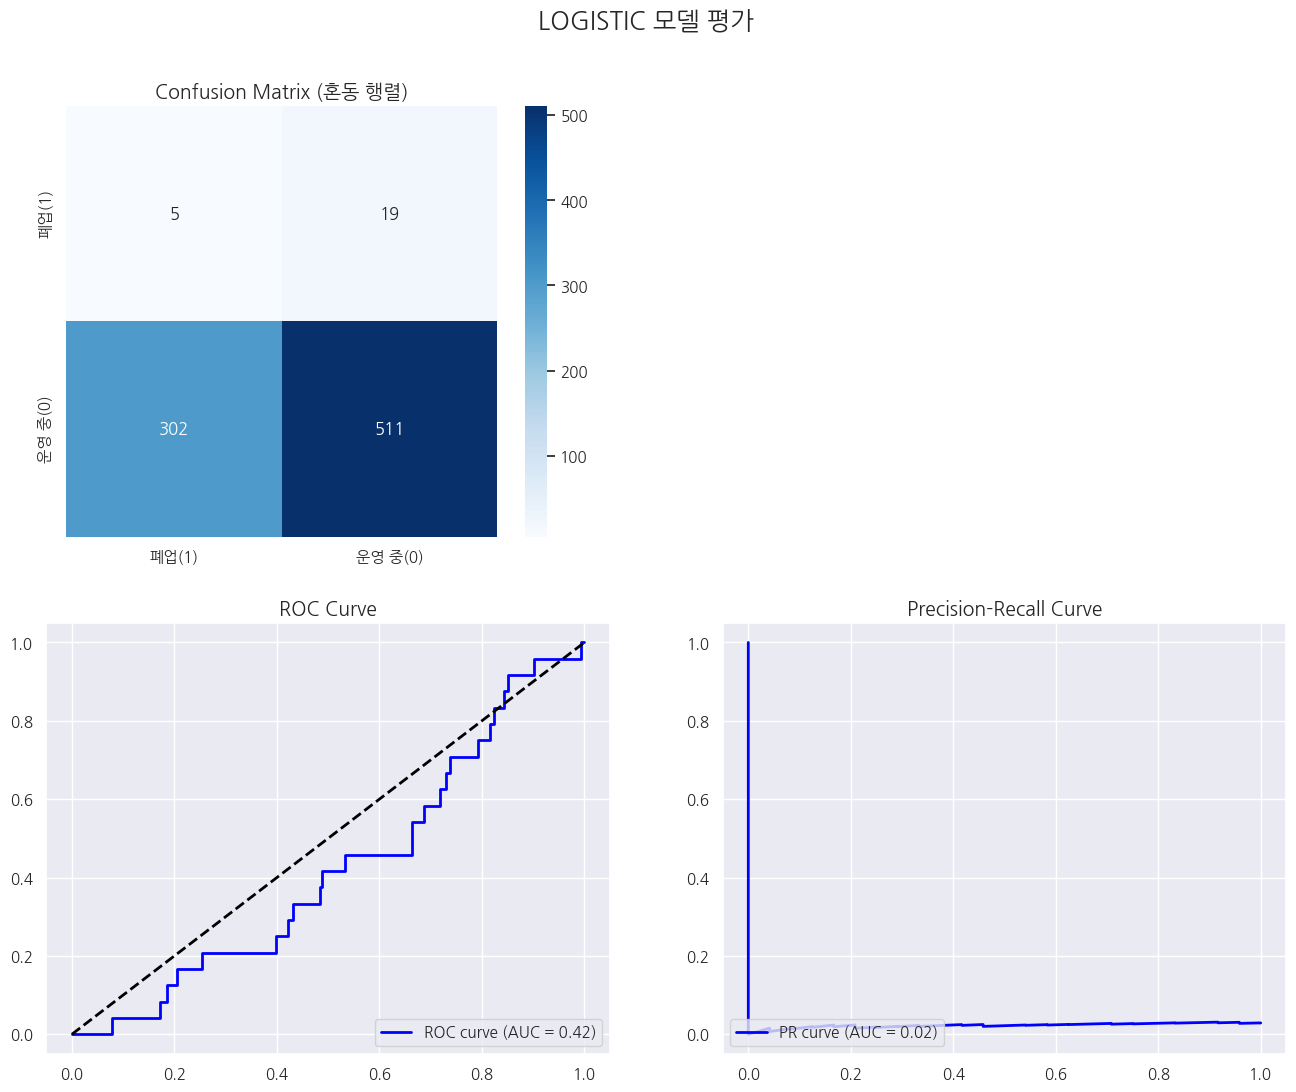

In [23]:
ModelTuner('logistic',X_train, X_test,y_train,y_test).run()

### Gaussian Naive Bayes

--- Gaussian Naive Bayes 모델 평가 ---
정확도(Accuracy): 0.1828
정밀도(Precision): 0.0299
재현율(Recall): 0.8750
F1 점수(F1 Score): 0.0579
매튜 상관 계수(MCC): 0.0170



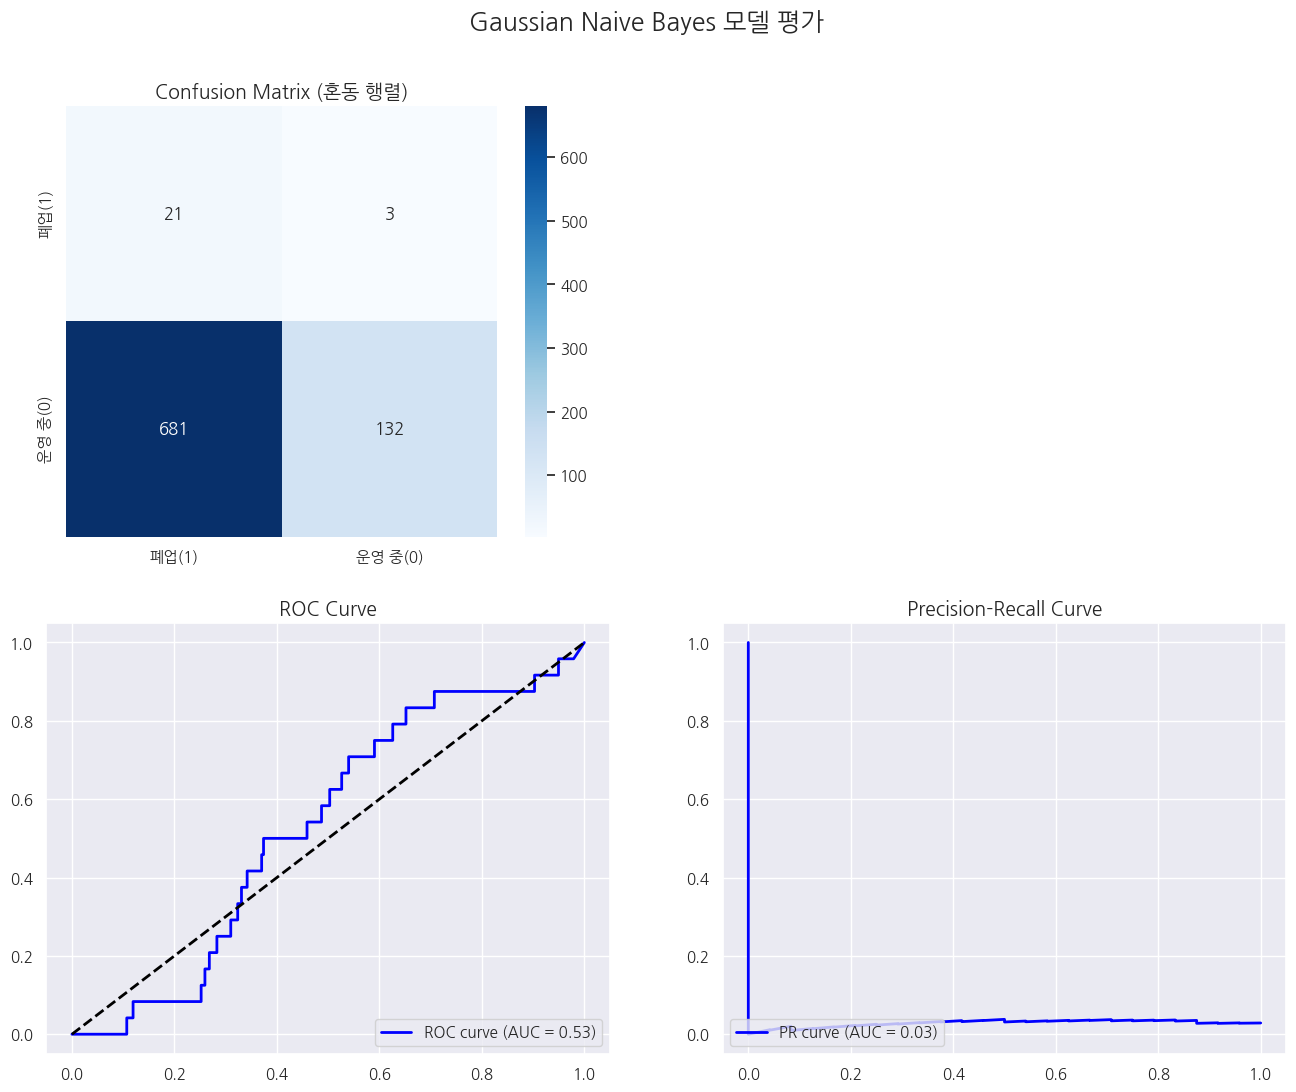

In [24]:
# Gaussian Naive Bayes
model=GaussianNB()
model.fit(X_train,y_train)

#가우시안은 X 데이터에 .toarray() 붙이기
model_eval(model,"Gaussian Naive Bayes",X_test,y_test)

--- gnb 모델의 하이퍼파라미터 튜닝 시작 ---
100%|████████████████████████████████████| 50/50 [00:00<00:00, 56.70trial/s, best loss: -0.8823809523809525]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'var_smoothing': np.float64(1.9675490801855302e-10)}


최종 모델 학습 완료.
--- GNB 모델 평가 ---
정확도(Accuracy): 0.1673
정밀도(Precision): 0.0294
재현율(Recall): 0.8750
F1 점수(F1 Score): 0.0568
매튜 상관 계수(MCC): 0.0101



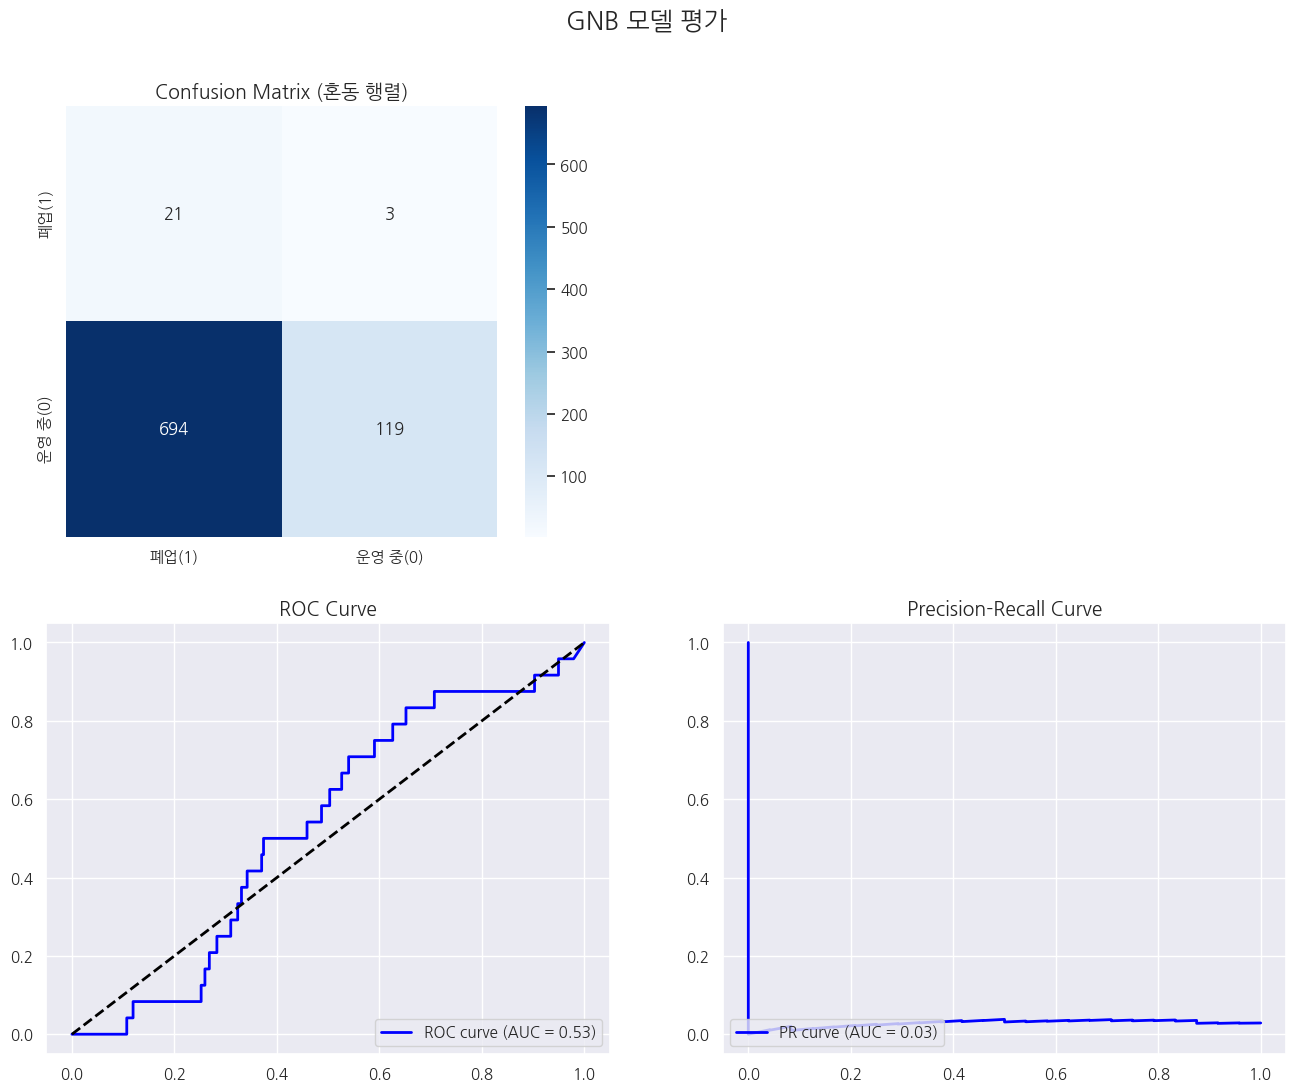

In [25]:
ModelTuner('gnb',X_train, X_test,y_train,y_test).run()

### KNN(K-Nearest Neighbours)

--- K-Nearest Neighbours 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



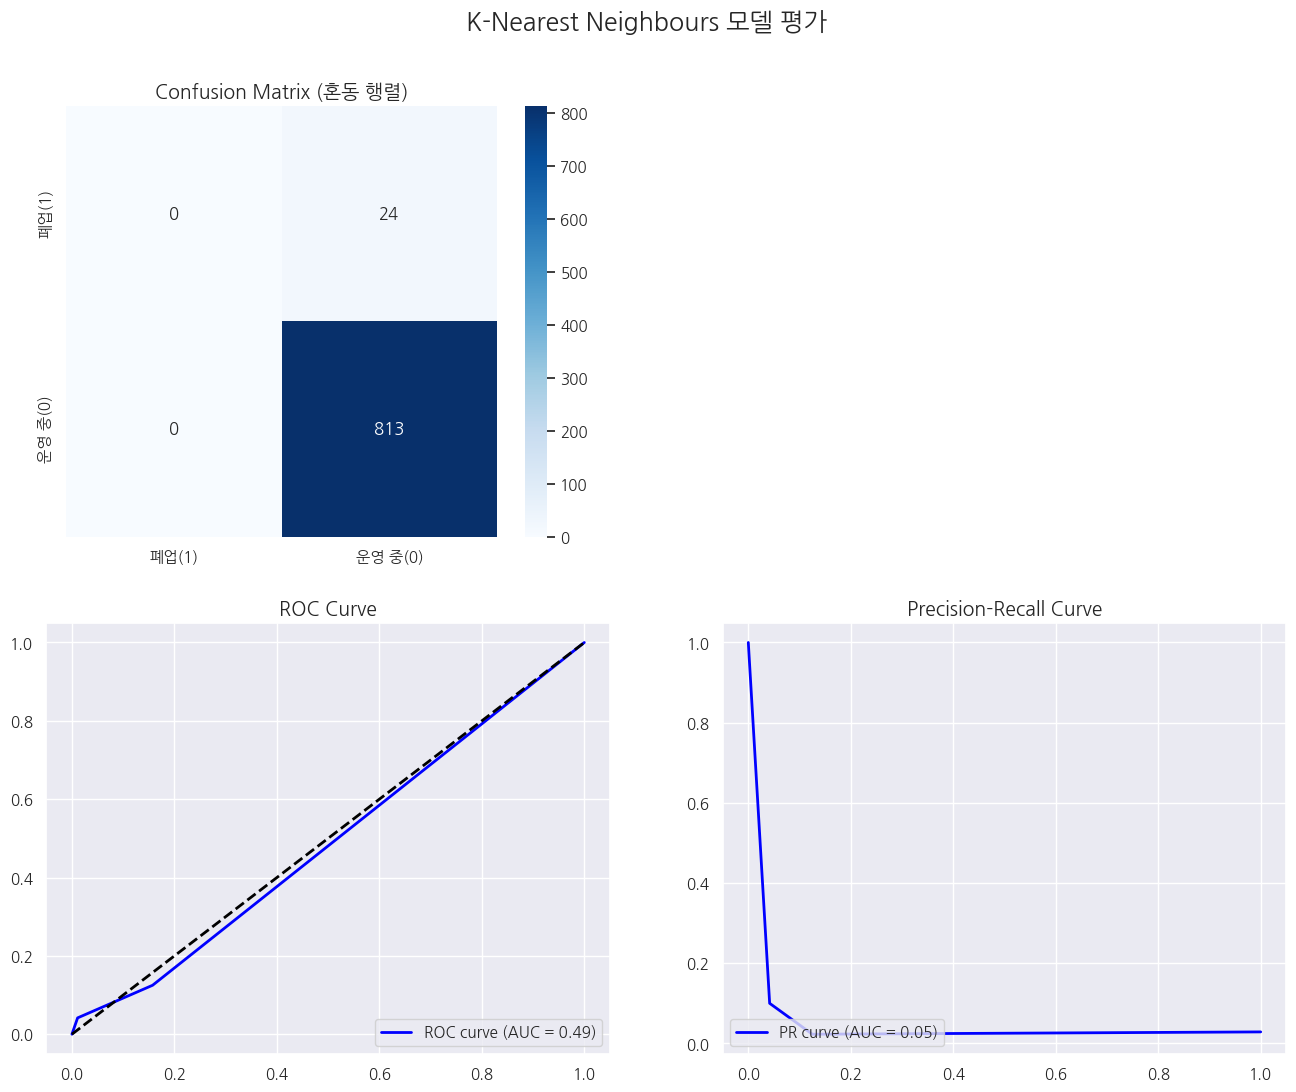

In [26]:
#K-Nearest Neighbours(KNN)
model=KNeighborsClassifier() 
model.fit(X_train,y_train)

model_eval(model,"K-Nearest Neighbours",X_test,y_test)

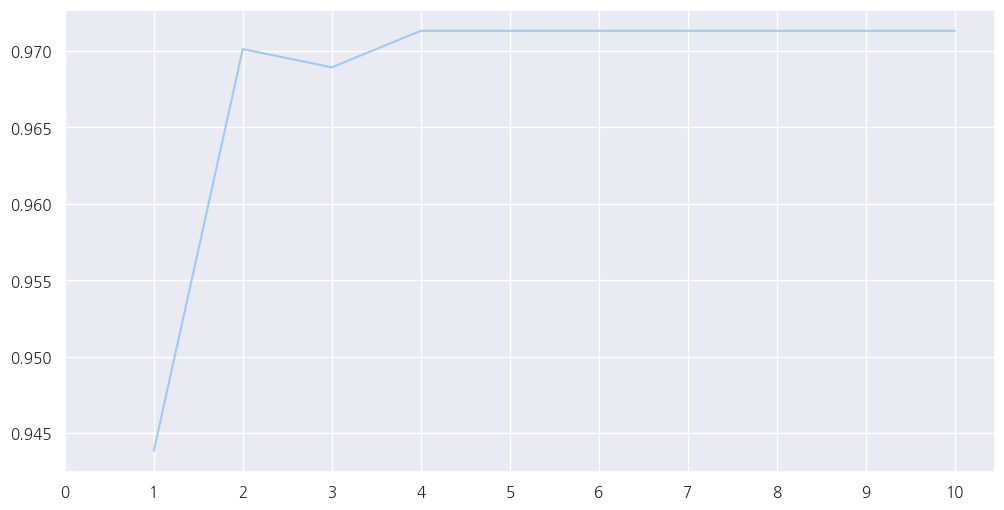

Accuracies for different values of n are: [0.94384707 0.97013142 0.96893668 0.97132616 0.97132616 0.97132616
 0.97132616 0.97132616 0.97132616 0.97132616] with the max value as  0.9713261648745519


In [27]:
#KNN 모델에서 N-neighbours 수를 늘려가며 정확도를 계산
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i) 
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)
    score = pd.Series([metrics.accuracy_score(prediction,y_test)])
    a = pd.concat([a, score], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

--- knn 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.70trial/s, best loss: -0.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'metric': 'minkowski', 'n_neighbors': np.float64(32.0), 'weights': 'uniform'}


최종 모델 학습 완료.
--- KNN 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



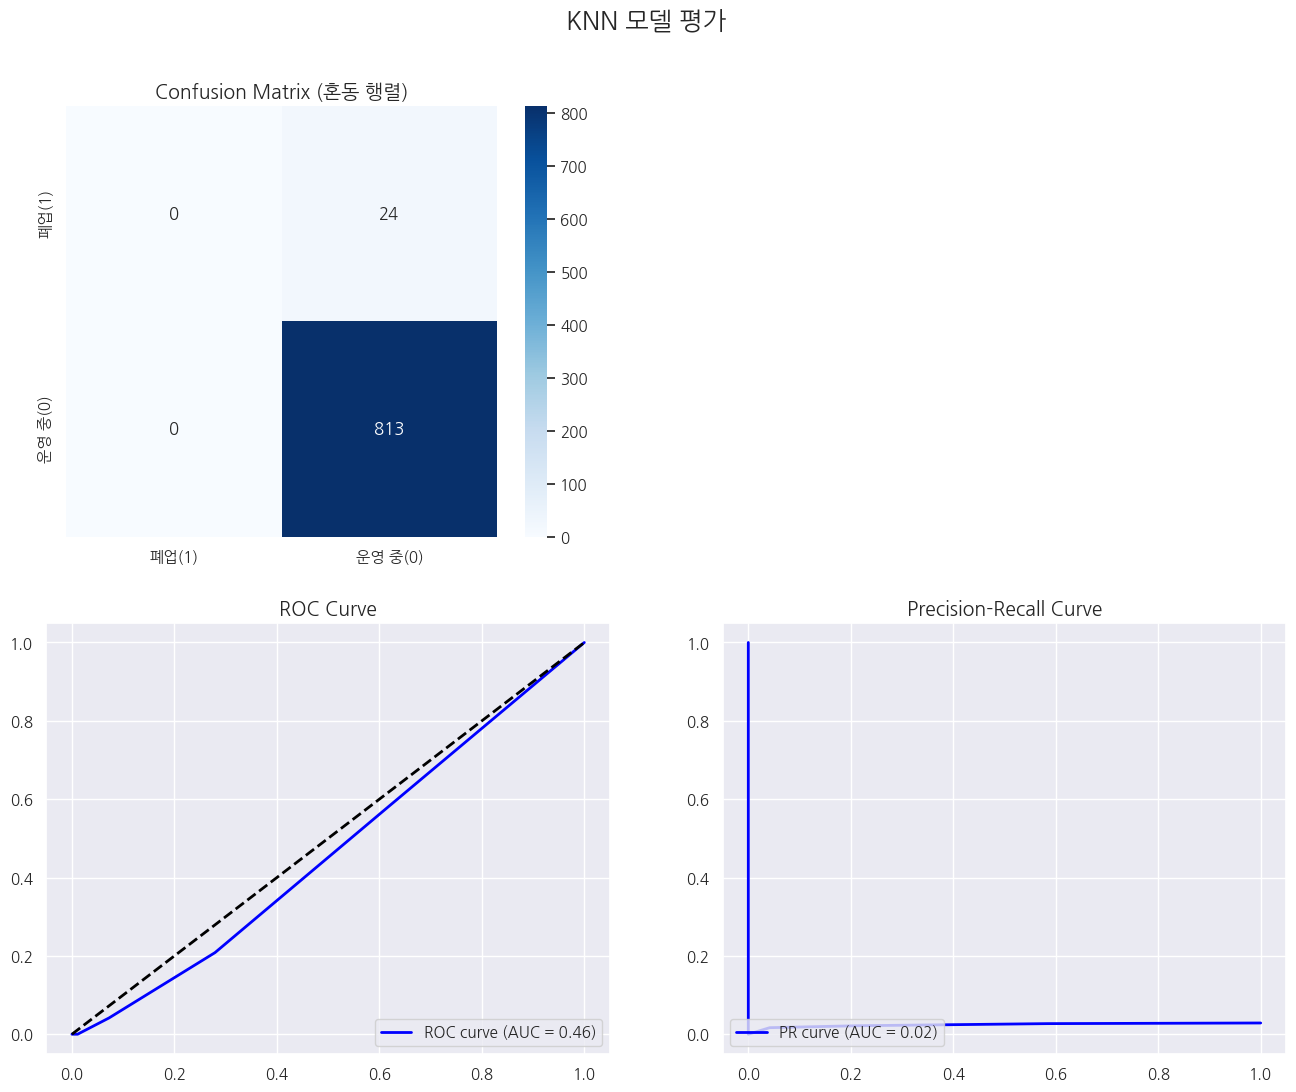

In [28]:
ModelTuner('knn',X_train, X_test,y_train,y_test).run()

### Support Vector Machine

--- Linear Support Vector Machine 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



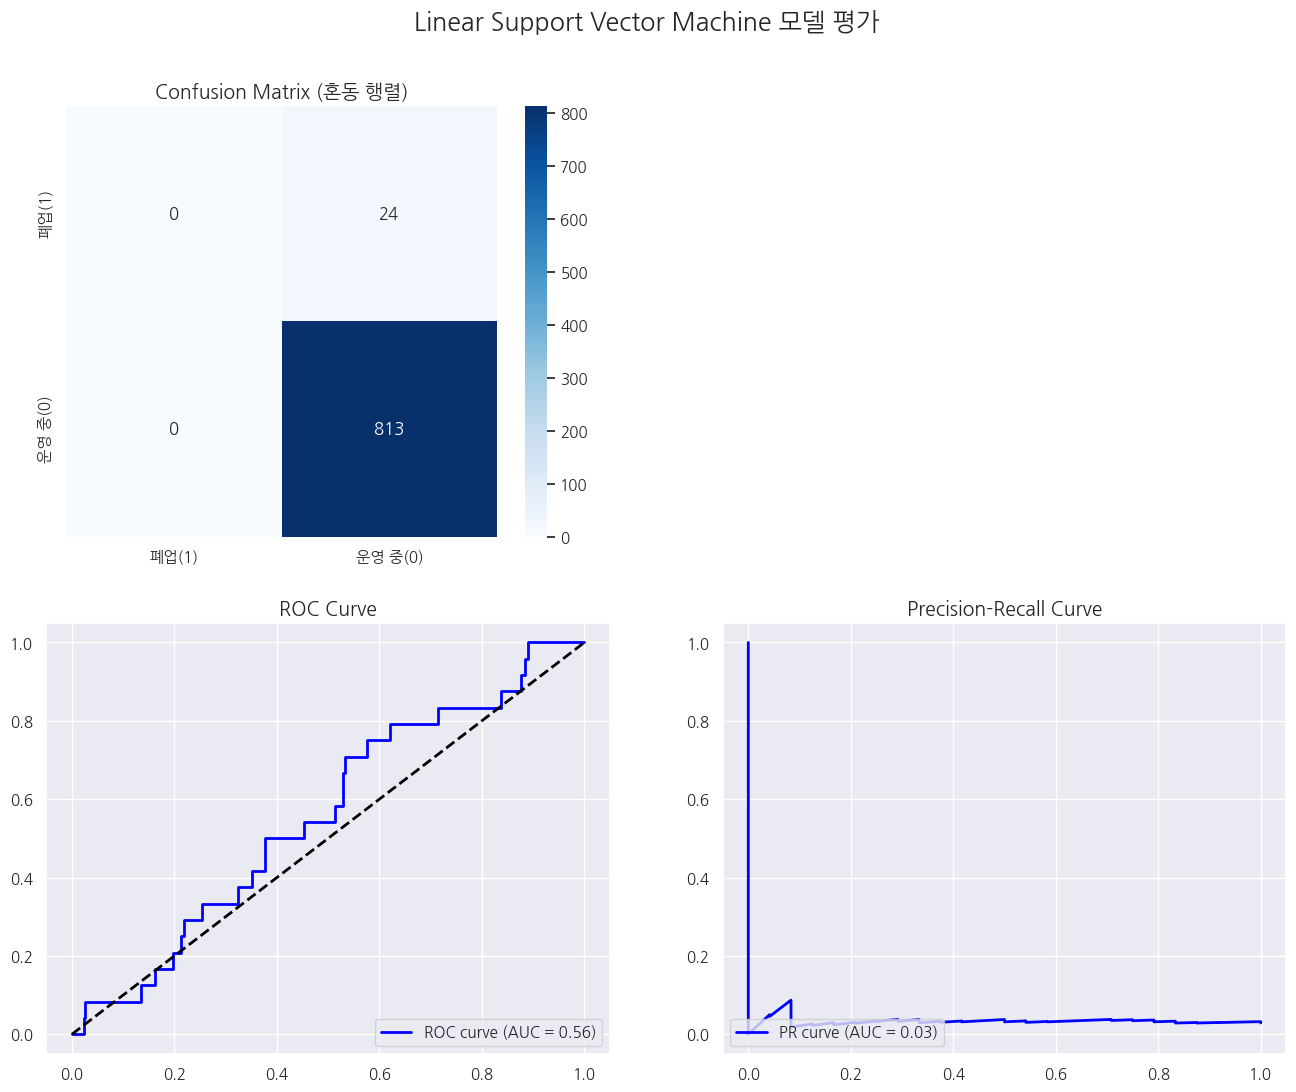

In [29]:
#Linear Support Vector Machine(linear-SVM)
model=svm.SVC(probability=True,kernel='linear',C=0.1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Linear Support Vector Machine",X_test,y_test)

In [ ]:
ModelTuner('svc_linear',X_train, X_test,y_train,y_test).run()

--- Radial Support Vector Machines 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



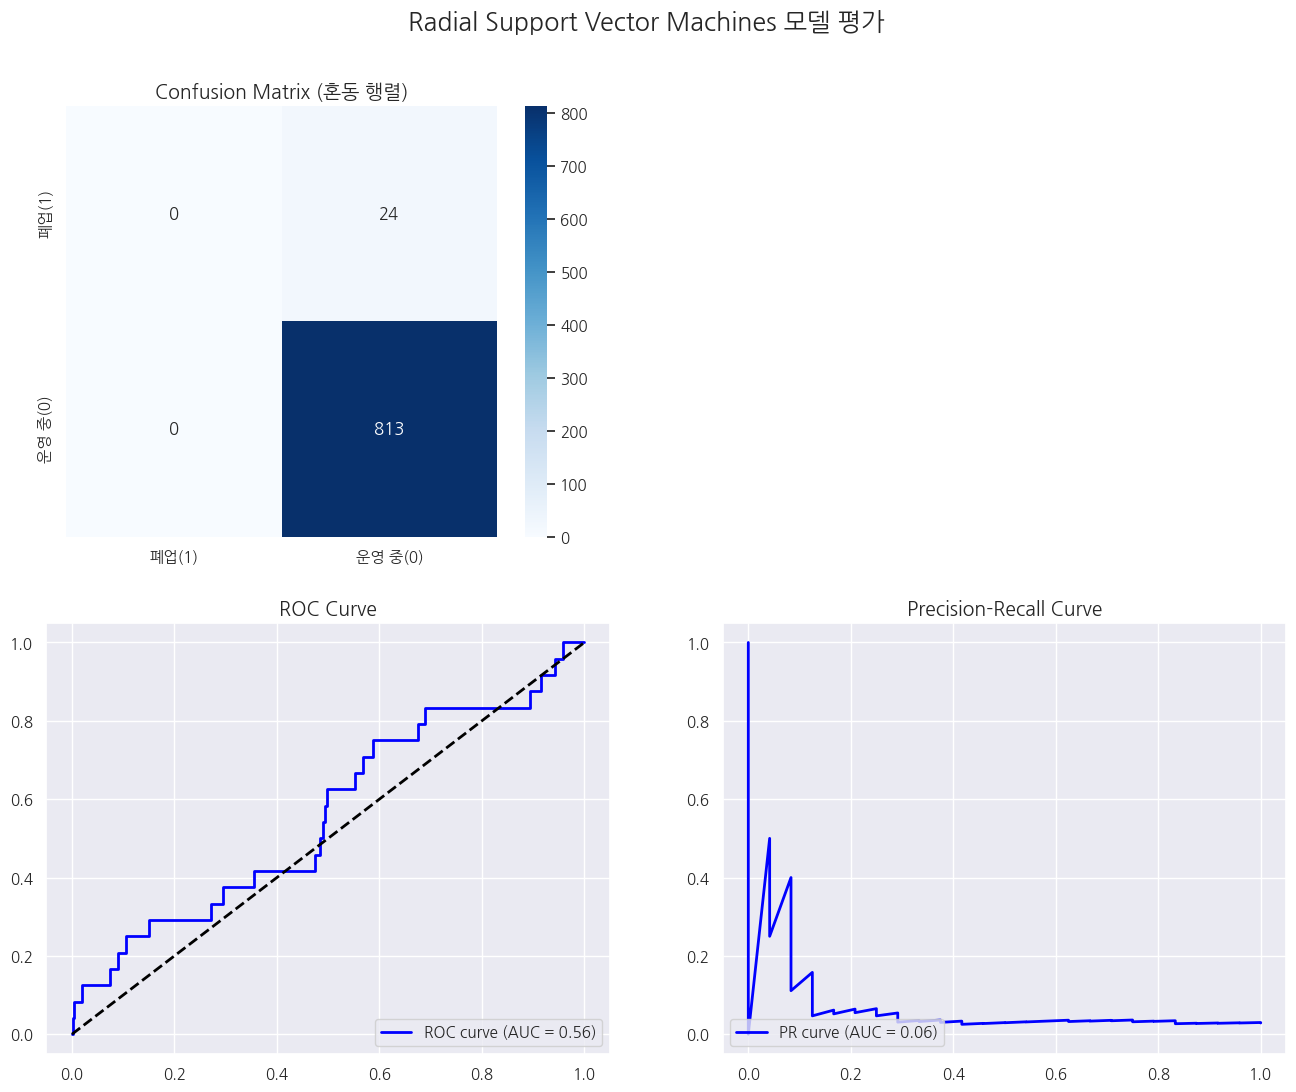

In [30]:
#Radial Support Vector Machines(rbf-SVM)
model=svm.SVC(probability=True,kernel='rbf',C=1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Radial Support Vector Machines",X_test,y_test)

--- svc_rbf 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [03:09<00:00,  3.78s/trial, best loss: -1.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(0.022667696660035788), 'class_weight': 'balanced', 'gamma': np.float64(0.00018607657136529177)}


최종 모델 학습 완료.
--- SVC_RBF 모델 평가 ---
정확도(Accuracy): 0.0287
정밀도(Precision): 0.0287
재현율(Recall): 1.0000
F1 점수(F1 Score): 0.0557
매튜 상관 계수(MCC): 0.0000



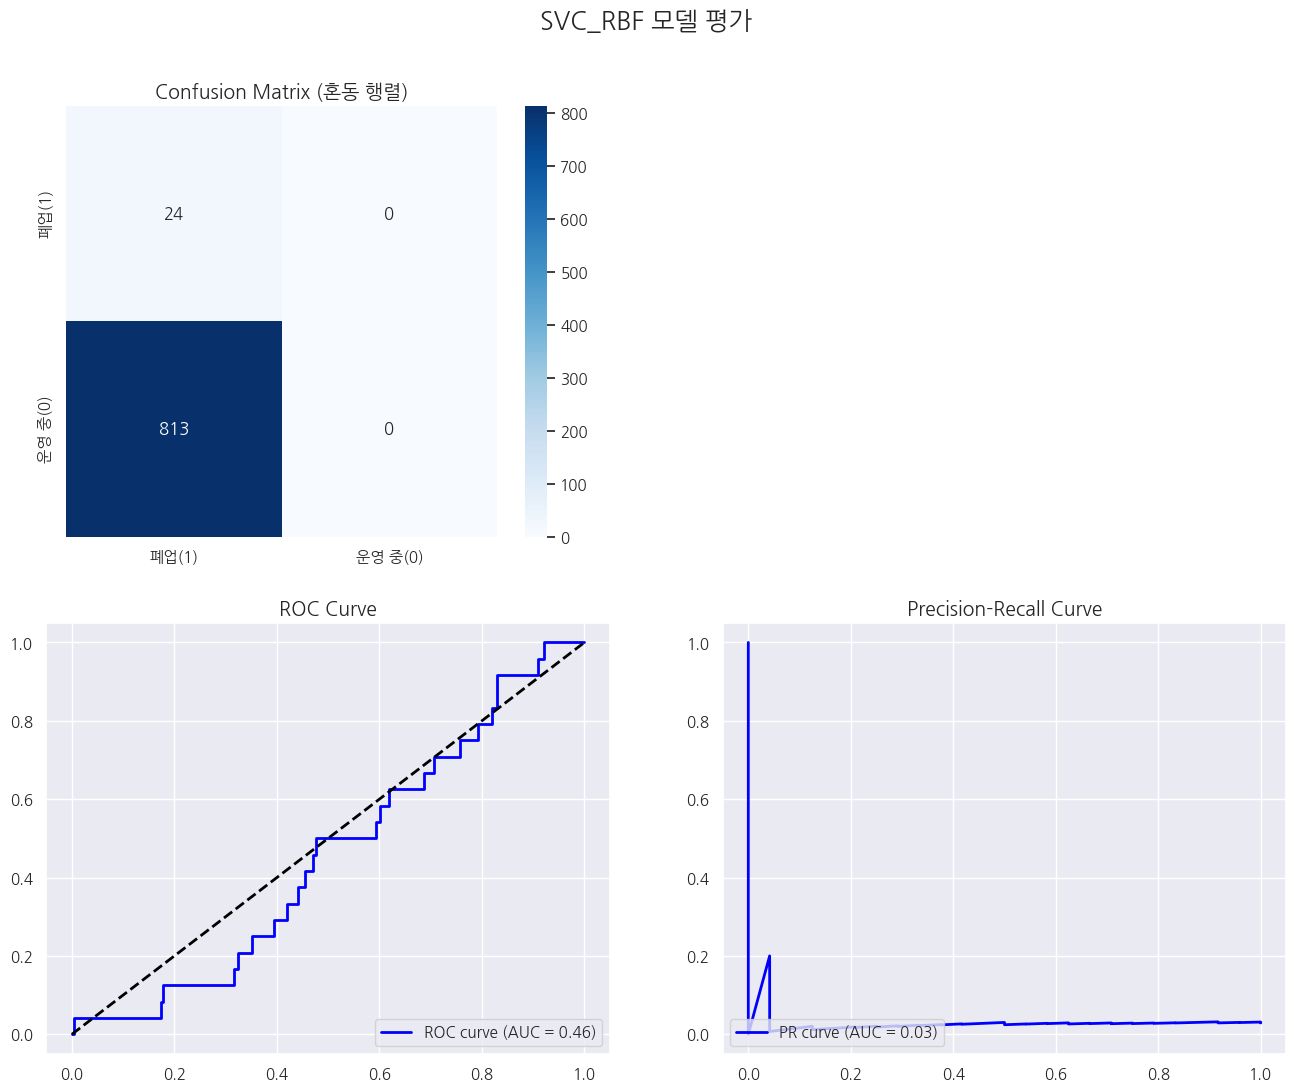

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_spl

In [31]:
ModelTuner('svc_rbf',X_train, X_test,y_train,y_test).run()

### Light Gradient Boosting Machine

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] Number of positive: 82, number of negative: 2596
[LightGBM] [Info] Total Bins 5759
[LightGBM] [Info] Number of data points in the train set: 2678, number of used features: 46
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	training's binary_logloss: 0.024231	valid_1's binary_logloss: 0.164541
[LightGBM] [Warning] min_gain_to_split is s

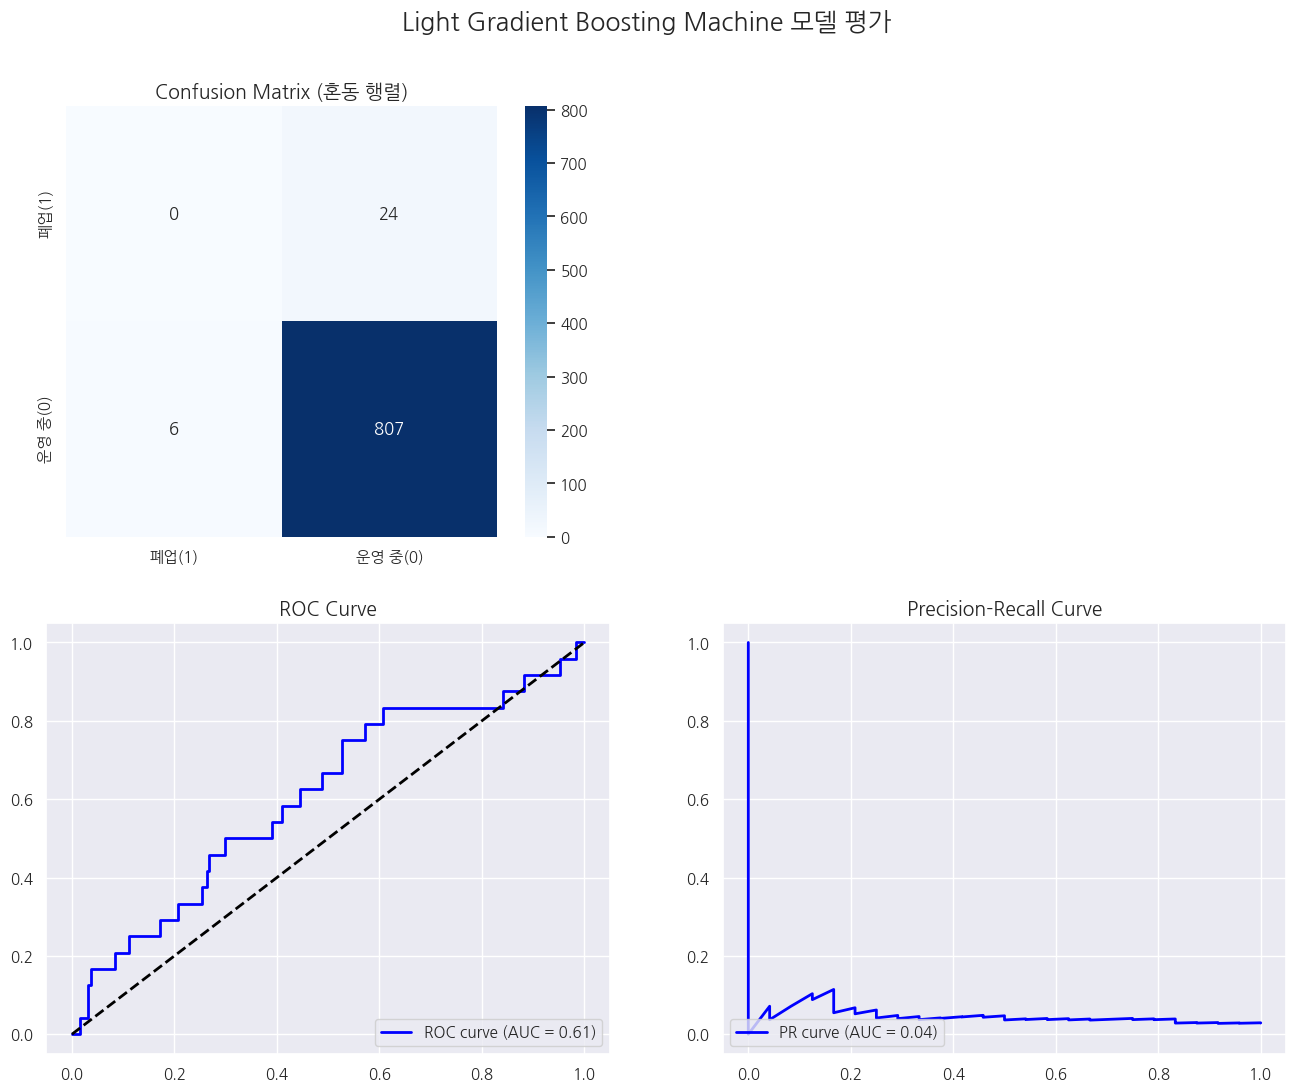

In [20]:
#GPU 사용안되면 device='cuda' 지우기
lgb_model = LGBMClassifier(
    device='cuda',
    n_estimators=500,
    learning_rate=0.05,
    class_weight = "balanced", #가중치추가
    subsample=0.8,
    colsample_bytree=0.8,
    min_gain_to_split=0.05,
    random_state=42,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)]
    ,callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=-1)]
)

model_eval(lgb_model,"Light Gradient Boosting Machine",X_test,y_test)

--- lgbm 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [05:18<00:00,  6.37s/trial, best loss: -0.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7936739623353964), 'learning_rate': np.float64(0.02639565625679032), 'max_depth': np.float64(12.0), 'min_child_samples': np.float64(30.0), 'n_estimators': np.float64(1600.0), 'num_leaves': np.float64(105.0), 'reg_alpha': np.float64(0.8839266254726155), 'reg_lambda': np.float64(0.620118997676641), 'subsample': np.float64(0.9254621630561151)}


최종 모델 학습 완료.
--- LGBM 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



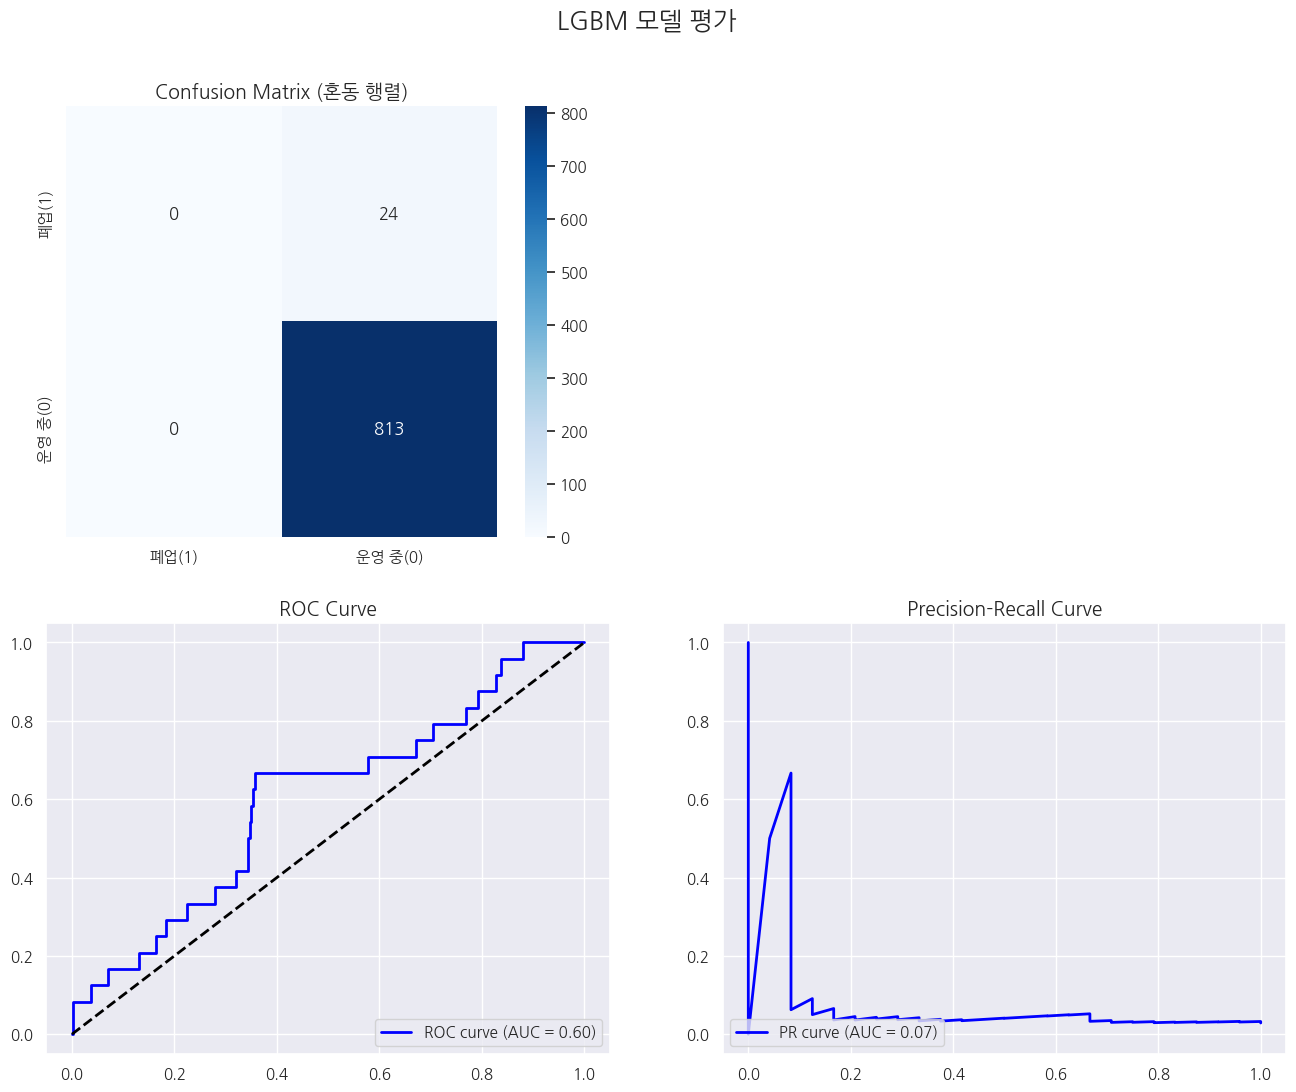

In [21]:
ModelTuner('lgbm',X_train, X_test,y_train,y_test).run()

### Exreme Gradient Boosting

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.9665
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): -0.0119



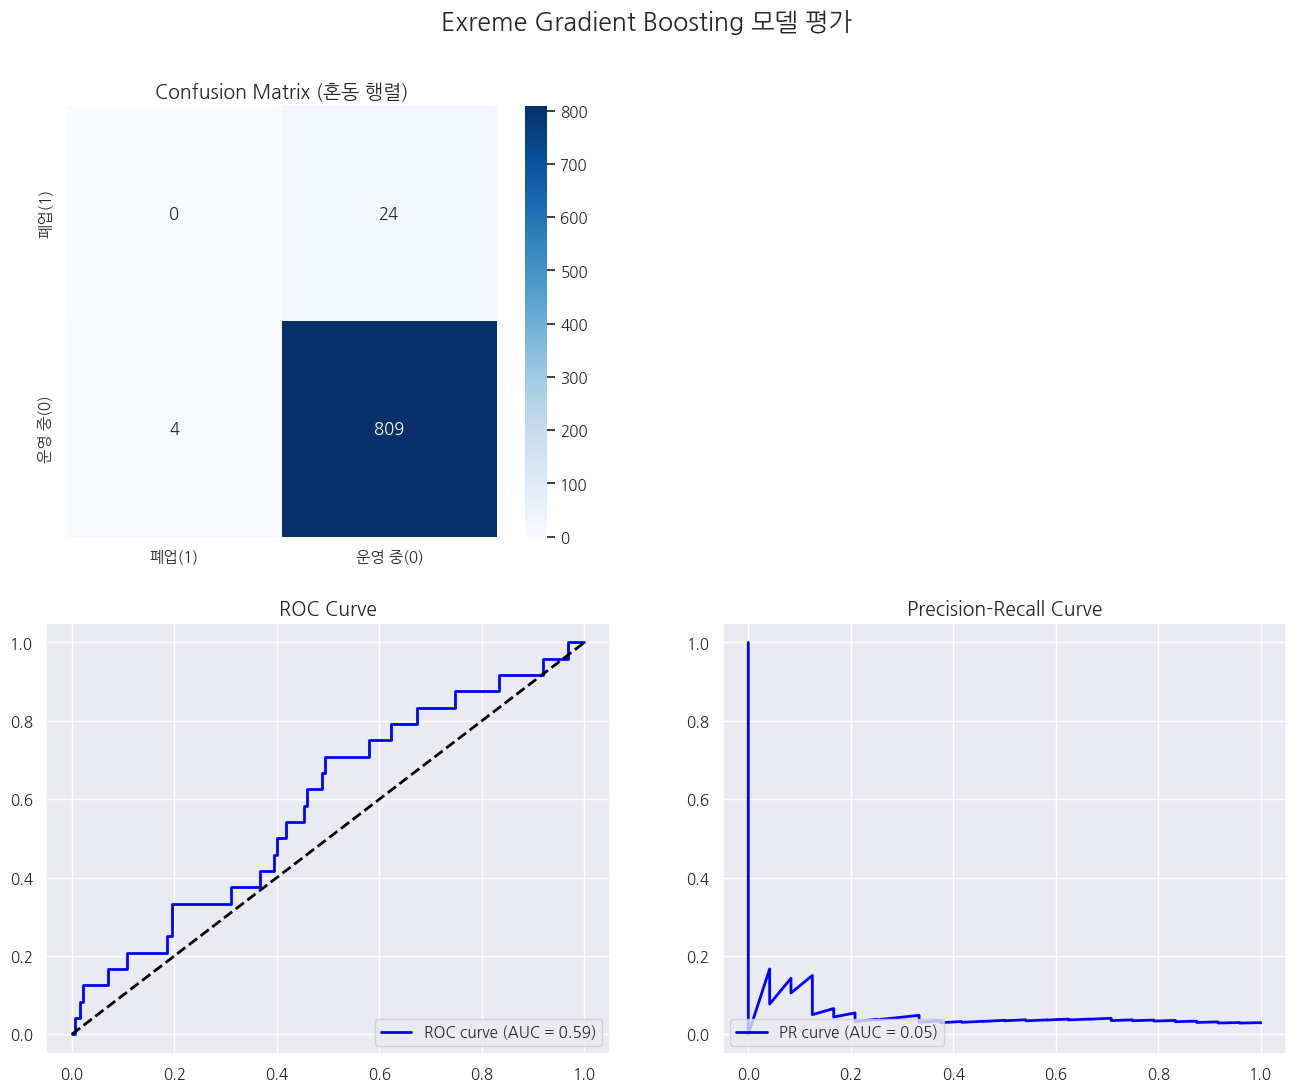

In [23]:
#GPU 사용안되면 tree_method = "hist", device = "cuda" 지우기
xgb_model = XGBClassifier(tree_method = "hist", device = "cuda",
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    early_stopping_rounds=50                      
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False
)

model_eval(xgb_model,"Exreme Gradient Boosting",X_test,y_test)

--- xgb 모델의 하이퍼파라미터 튜닝 시작 ---
100%|██████████████████████████████████████████████████| 50/50 [05:29<00:00,  6.59s/trial, best loss: -0.35]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7767014729172877), 'gamma': np.float64(0.18988818528184195), 'learning_rate': np.float64(0.021043880395931434), 'max_depth': np.float64(3.0), 'min_child_weight': np.float64(1.0), 'n_estimators': np.float64(100.0), 'scale_pos_weight': np.float64(36.75815791750555), 'subsample': np.float64(0.8295072584830219)}


최종 모델 학습 완료.
--- XGB 모델 평가 ---
정확도(Accuracy): 0.7133
정밀도(Precision): 0.0500
재현율(Recall): 0.5000
F1 점수(F1 Score): 0.0909
매튜 상관 계수(MCC): 0.0810



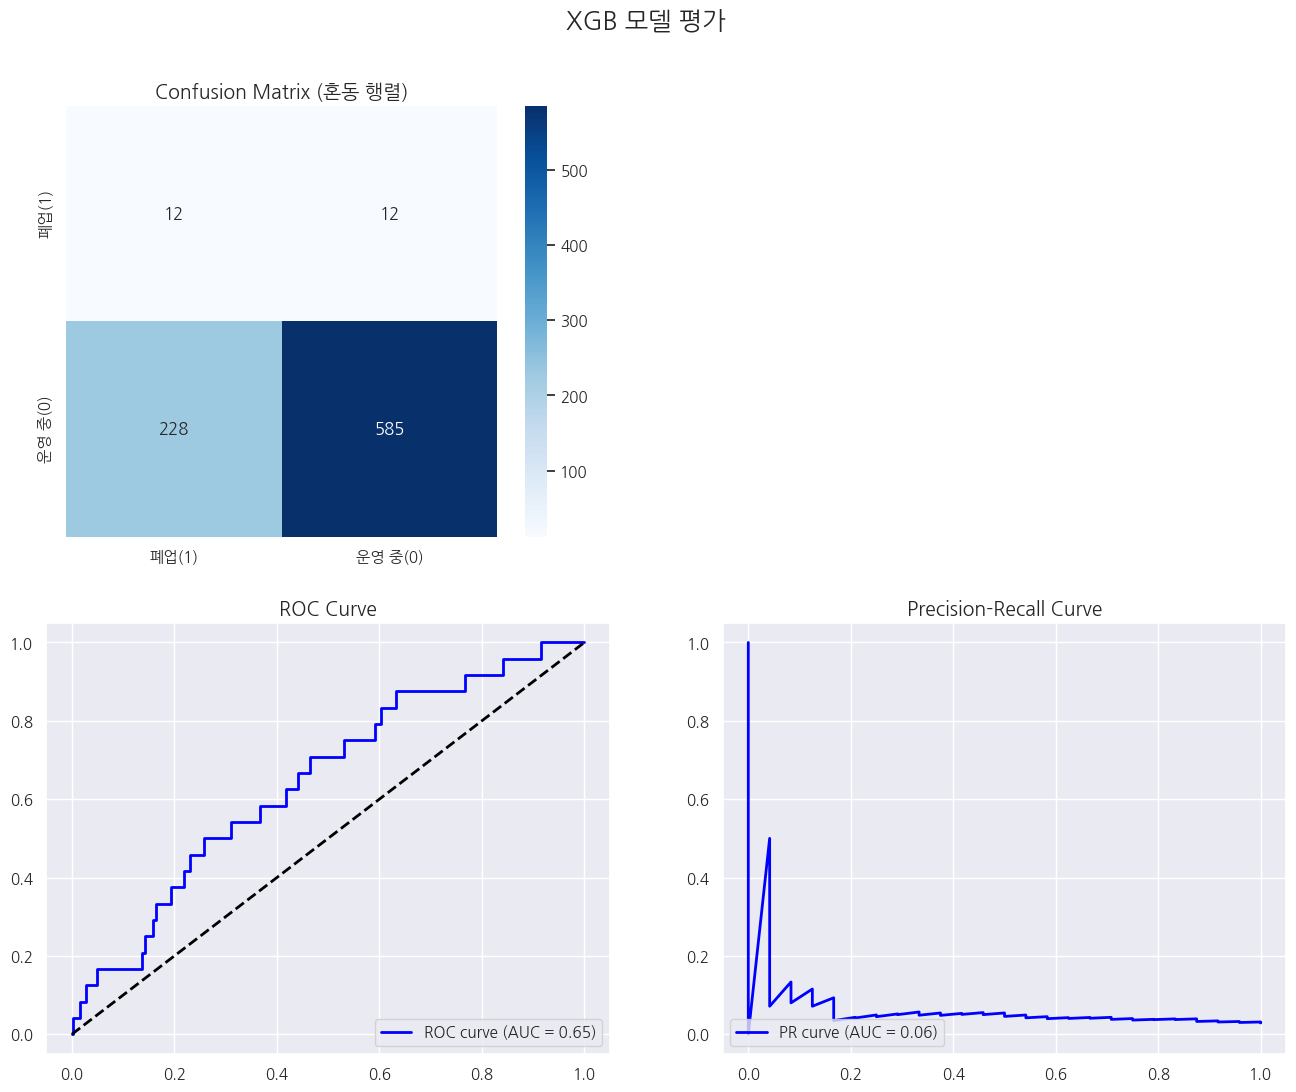

In [24]:
ModelTuner('xgb',X_train, X_test,y_train,y_test).run()

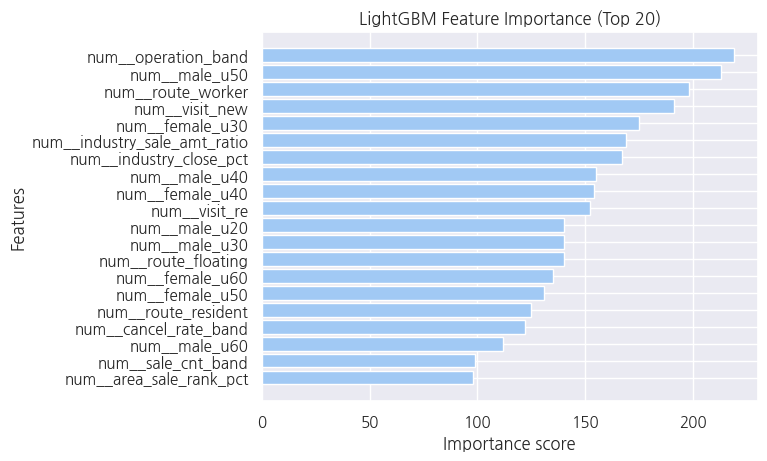

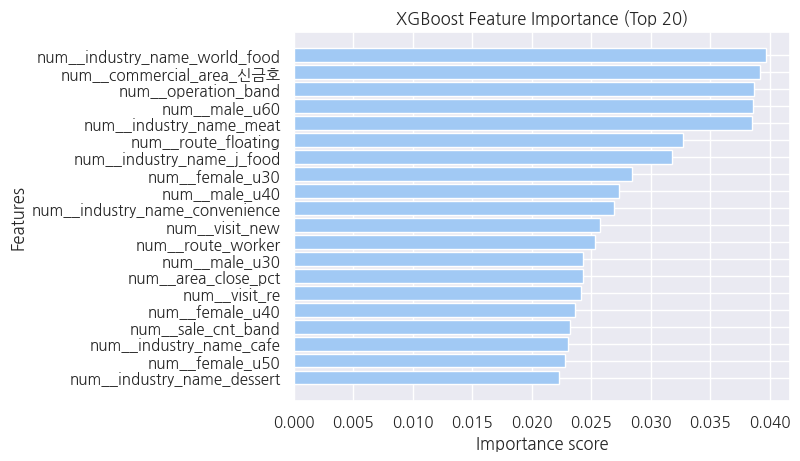

In [25]:
def plot_feature_importance(model_name, features, importances, top_n=20):
    idx = np.argsort(importances)[::-1][:top_n]
    plt.barh(np.array(features)[idx][::-1], np.array(importances)[idx][::-1])
    plt.title(f"{model_name} Feature Importance (Top {top_n})")
    plt.xlabel("Importance score")
    plt.ylabel("Features")
    plt.show()


# LightGBM
fi_lgb = lgb_model.feature_importances_
plot_feature_importance("LightGBM", X_val.columns, fi_lgb)

# XGBoost
fi_xgb = xgb_model.feature_importances_  # numpy array
plot_feature_importance("XGBoost", X_val.columns, fi_xgb)

# CatBoost
# fi_cat = cat_model.get_feature_importance()
# plot_feature_importance("CatBoost", X_val.columns, fi_cat)

                           feature  importance
0              num__operation_band         0.0
1               num__sale_cnt_band         0.0
2                    num__aov_band         0.0
3            num__cancel_rate_band         0.0
4  num__delivery_sale_amount_ratio         0.0
5     num__industry_sale_amt_ratio         0.0
6          num__area_sale_rank_pct         0.0
7          num__industry_close_pct         0.0
8              num__area_close_pct         0.0
9                    num__male_u20         0.0


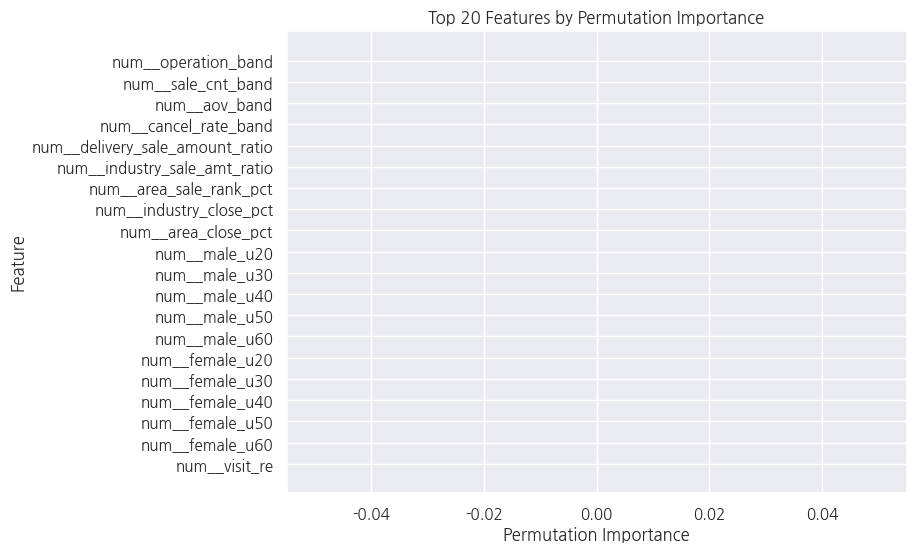

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
    
)

import pandas as pd

fi = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi.head(10))

top_features = fi.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

                           feature  importance
0              num__operation_band         0.0
1               num__sale_cnt_band         0.0
2                    num__aov_band         0.0
3            num__cancel_rate_band         0.0
4  num__delivery_sale_amount_ratio         0.0
5     num__industry_sale_amt_ratio         0.0
6          num__area_sale_rank_pct         0.0
7          num__industry_close_pct         0.0
8              num__area_close_pct         0.0
9                    num__male_u20         0.0


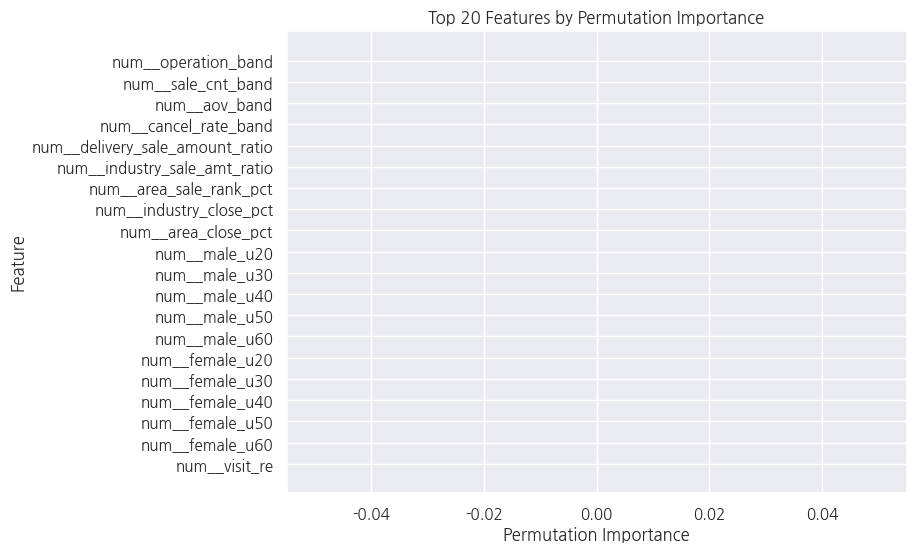

In [29]:
result_xgb = permutation_importance(
    xgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
     
)

fi_xgb = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result_xgb.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi_xgb.head(10))

top_features_xgb = fi_xgb.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features_xgb["feature"], top_features_xgb["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

### Deep Learning